# ECON 424 Final Project
Ethan Tran

November 2025

# Q1.
The following introduces the data set.

The data are Glassdoor reviews. Training data sets (small: 100,00 observations, large: 500,000 observations; small is not a subset of large; you can use both training sets) are posted on Learn. 

The test data set has 100,000 observations. Test data set without the response variable is also already posted on Learn.

Some feature variables may have missing values. In the prediction competition you cannot skip observations with missing values on some features: you must give some prediction for all 100,000 observations in the test set.

### a)

Construct features from the available data. Then use these features to predict the overall rating using any machine learning model. (For this question, you should not use LLM APIs.)

You can utilize either or both training data sets to train the model.

Performance of the algorithm is measured by the accuracy percentage in the test set.

In [155]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from wordcloud import WordCloud
import lightgbm as lgb

In [156]:
# Load data
train_small = pd.read_csv("424_F2025_Final_PC_small_train_v1.csv")
train_large = pd.read_csv("424_F2025_Final_PC_large_train_v1.csv")
test_ds = pd.read_csv("424_F2025_Final_PC_test_without_response_v1.csv")
ds = pd.concat([train_small, train_large], ignore_index=True)

text_cols = ["headline", "pros", "cons"]
cat_cols = ["firm", "job_title"]
num_cols = ["year_review"]
target = "rating"

# Fill missing
for c in text_cols:
    ds[c] = ds[c].fillna("")
    test_ds[c] = test_ds[c].fillna("")
for c in cat_cols:
    ds[c] = ds[c].fillna("Unknown")
    test_ds[c] = test_ds[c].fillna("Unknown")

In [157]:
# Feature engineering
ds["full_text"] = ds["headline"] + " " + ds["pros"] + " " + ds["cons"]
test_ds["full_text"] = test_ds["headline"] + " " + test_ds["pros"] + " " + test_ds["cons"]

In [158]:
# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    ds, ds[target], test_size=0.2, random_state=42
)

In [159]:
# Column transformer
tfidf = TfidfVectorizer(
    max_features=60000,
    ngram_range=(1, 2),
    stop_words="english"
)

ohe = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer(
    transformers=[
        ("text", tfidf, "full_text"),
        ("cat", ohe, cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

In [160]:
# Model
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8
)

pipeline = Pipeline([
    ("prep", preprocess),
    ("model", model)
])

In [161]:
# Train model
pipeline.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 20.854338 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1183801
[LightGBM] [Info] Number of data points in the train set: 480000, number of used features: 59708
[LightGBM] [Info] Start training from score -2.935735
[LightGBM] [Info] Start training from score -2.601609
[LightGBM] [Info] Start training from score -1.442353
[LightGBM] [Info] Start training from score -1.050805
[LightGBM] [Info] Start training from score -1.249224


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [162]:
# Training accuracy
train_pred = pipeline.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print("Training Accuracy:", train_acc * 100)

d:\Stuff\School\UWaterloo\fall 2025\ECON 424\Final Project\ECON424-Final\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Accuracy: 59.236875


In [163]:
# Validation accuracy
val_pred = pipeline.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)
print("Validation Accuracy:", val_acc * 100)

d:\Stuff\School\UWaterloo\fall 2025\ECON 424\Final Project\ECON424-Final\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation Accuracy: 51.57083333333333


In [164]:
# Fit on full data
pipeline.fit(ds, ds[target])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 25.532525 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1189484
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 62187
[LightGBM] [Info] Start training from score -2.938628
[LightGBM] [Info] Start training from score -2.602452
[LightGBM] [Info] Start training from score -1.443098
[LightGBM] [Info] Start training from score -1.051328
[LightGBM] [Info] Start training from score -1.247223


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [165]:
# Predict
test_pred = pipeline.predict(test_ds)

# Save prediction CSV in competition format
out = pd.DataFrame({
    "prediction": test_pred
})
out.to_csv("Q1_submission_predictions.csv", index=False)
print("Saved predictions to Q1_submission_predictions.csv")

d:\Stuff\School\UWaterloo\fall 2025\ECON 424\Final Project\ECON424-Final\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Saved predictions to Q1_submission_predictions.csv


### b)

Produce graphs to illustrate the following (we have drawn all of these in previous prediction competitions):

• Word cloud for 5 star reviews versus word cloud for 1 star reviews

• Importance of each feature.

• Distribution of each feature in the training data versus in the test data.

• Confusion matrix (in the training data).

• How large and common are prediction errors at different points of the distribution of the response variable in the training data (in other words, contrast distributions for y vs. ˆy, or distributions for y versus ˆu).

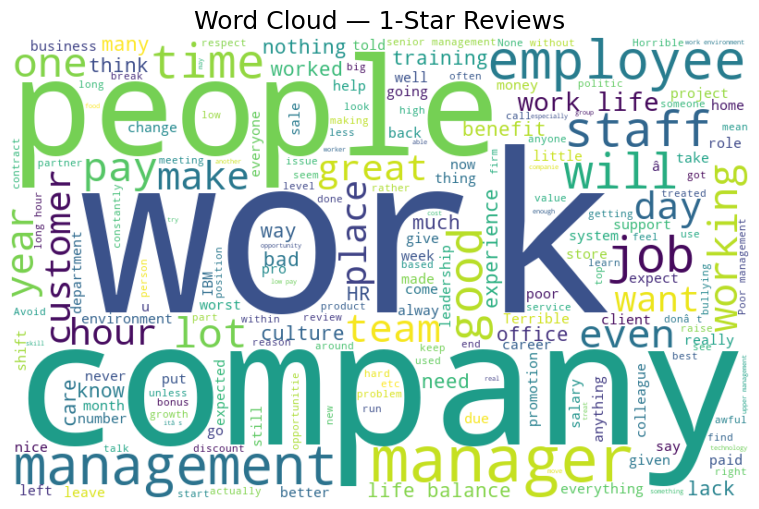

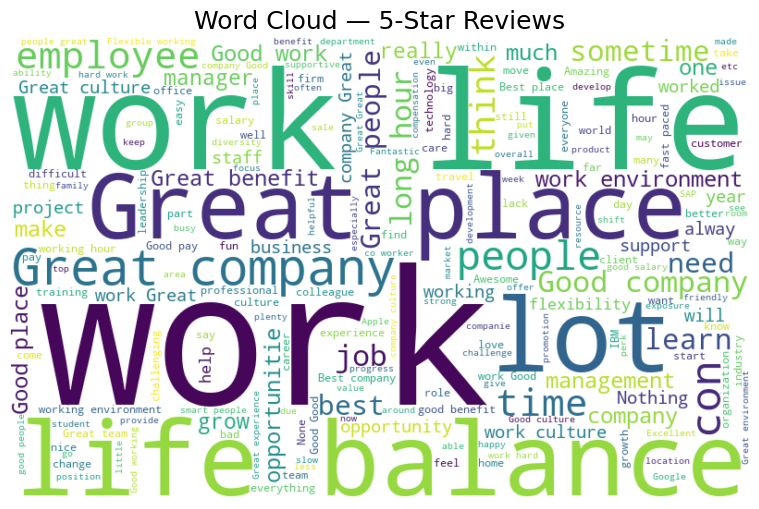

In [166]:
# Word cloud
def make_wordcloud(text, title):
    wc = WordCloud(width=800, height=500, background_color="white").generate(text)
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(title, fontsize=18)
    plt.axis("off")
    plt.show()

text_1 = " ".join(ds[ds[target] == 1]["full_text"].tolist())
text_5 = " ".join(ds[ds[target] == 5]["full_text"].tolist())

make_wordcloud(text_1, "Word Cloud — 1-Star Reviews")
make_wordcloud(text_5, "Word Cloud — 5-Star Reviews")

Number of features: 110408
Importance values: 110408


C:\Users\vecto\AppData\Local\Temp\ipykernel_23600\2344485911.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


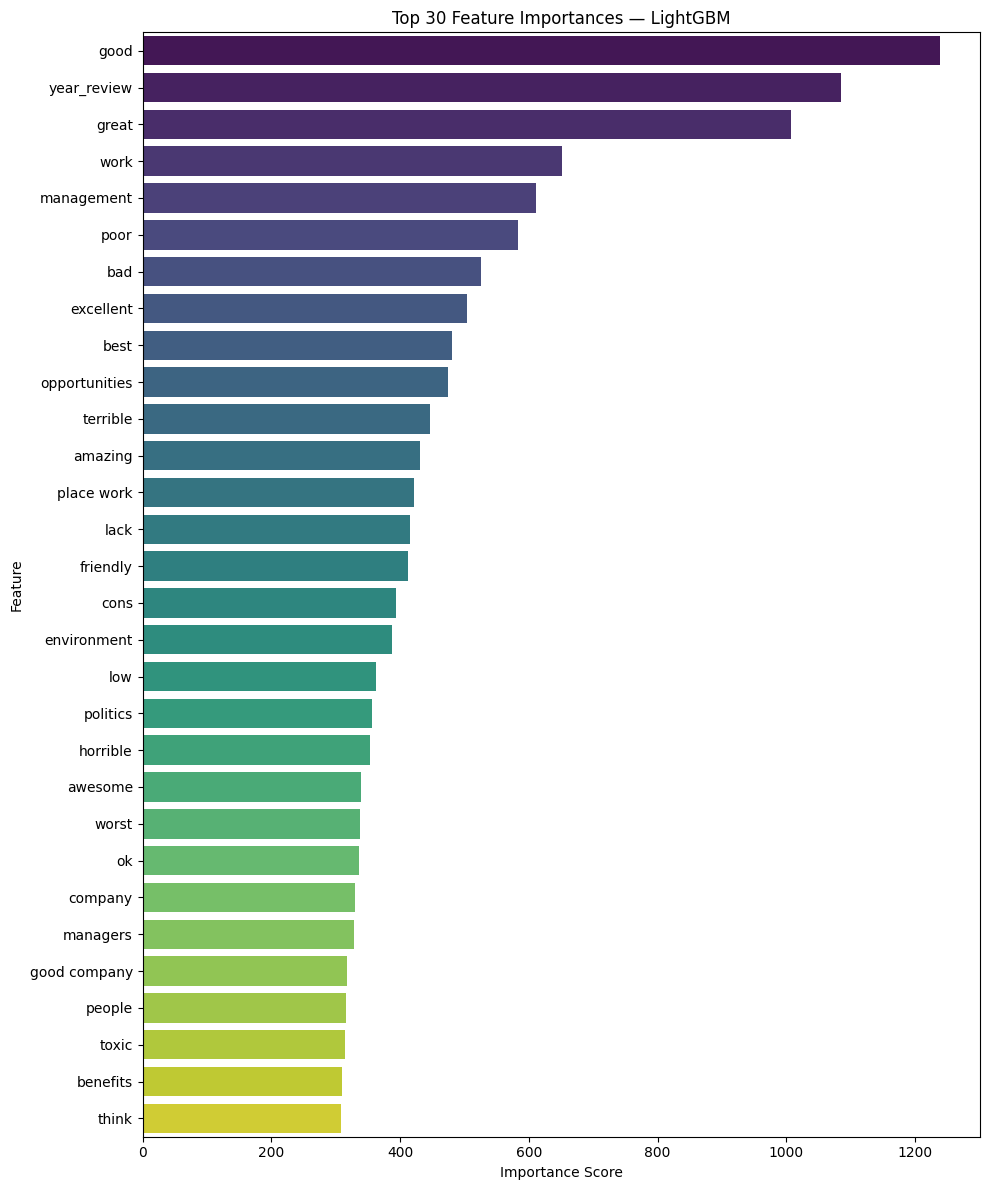

In [167]:
# Feature importance

# Extract fitted components
fitted_prep = pipeline.named_steps["prep"]
fitted_model = pipeline.named_steps["model"]

# ---- 1. Text feature names (TF-IDF) ----
tfidf_fitted = fitted_prep.named_transformers_["text"]
tfidf_features = tfidf_fitted.get_feature_names_out()

# ---- 2. OneHotEncoder feature names ----
ohe_fitted = fitted_prep.named_transformers_["cat"]
ohe_features = ohe_fitted.get_feature_names_out(cat_cols)

# ---- 3. Numeric features ----
numeric_features = num_cols

# Combine all feature names in correct order
all_features = np.concatenate([
    tfidf_features,
    ohe_features,
    numeric_features
])

# ---- 4. Extract feature importances from LightGBM ----
importances = fitted_model.feature_importances_

# Safety check (dimension alignment)
print("Number of features:", len(all_features))
print("Importance values:", len(importances))

# Create DataFrame
fi = pd.DataFrame({
    "feature": all_features,
    "importance": importances
})

# Sort and keep top 30 (otherwise text features dominate graph size)
fi_top = fi.sort_values("importance", ascending=False).head(30)

# ---- 5. Plot Feature Importance ----
plt.figure(figsize=(10, 12))
sns.barplot(
    data=fi_top,
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Top 30 Feature Importances — LightGBM")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

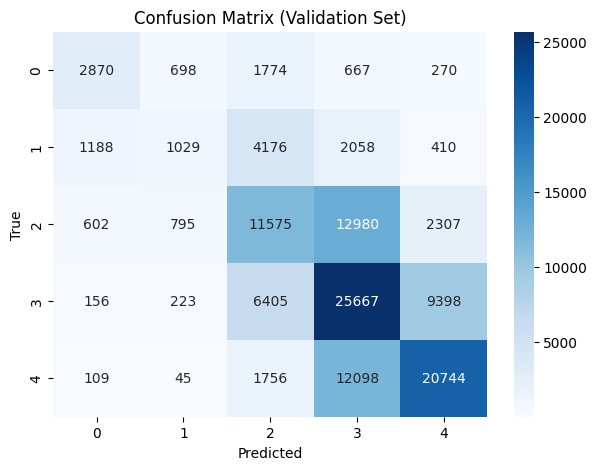

In [168]:
# Confusion matrix
cm = confusion_matrix(y_val, val_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Validation Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

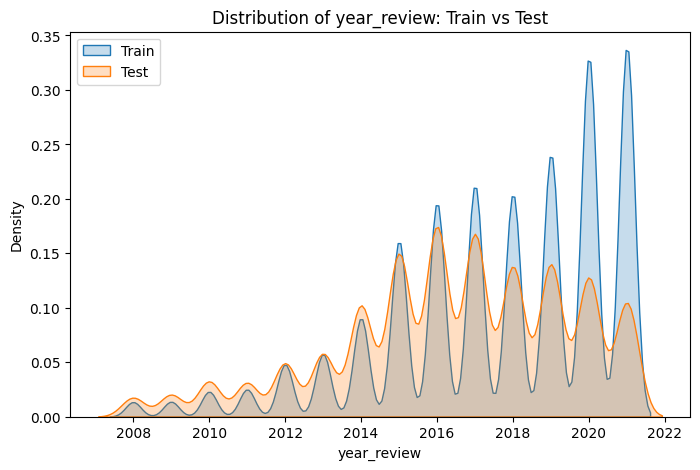

<Figure size 800x500 with 0 Axes>

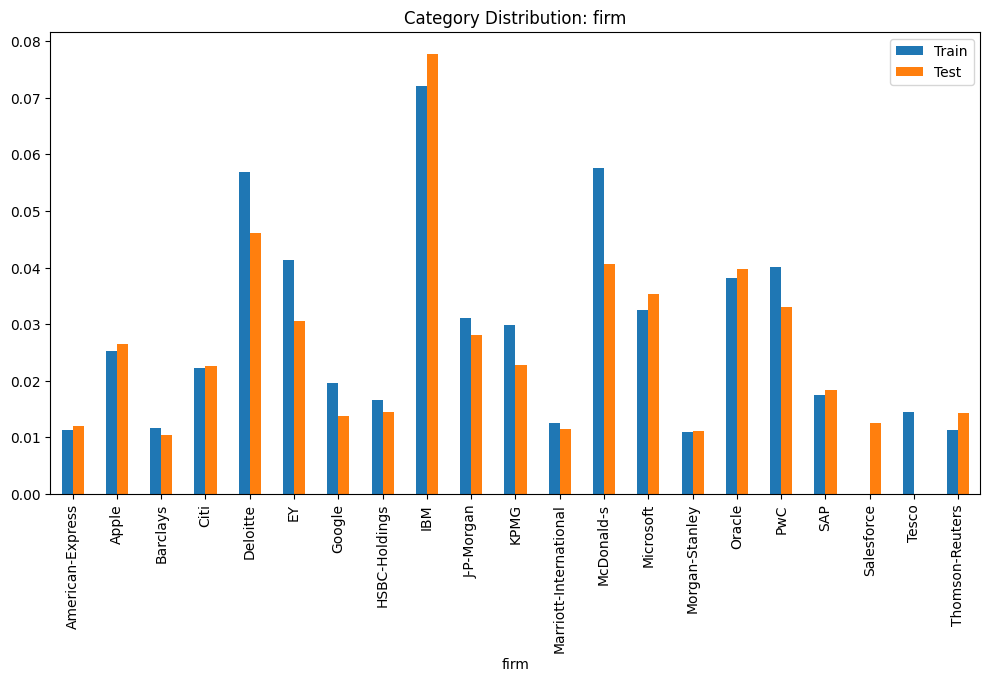

<Figure size 800x500 with 0 Axes>

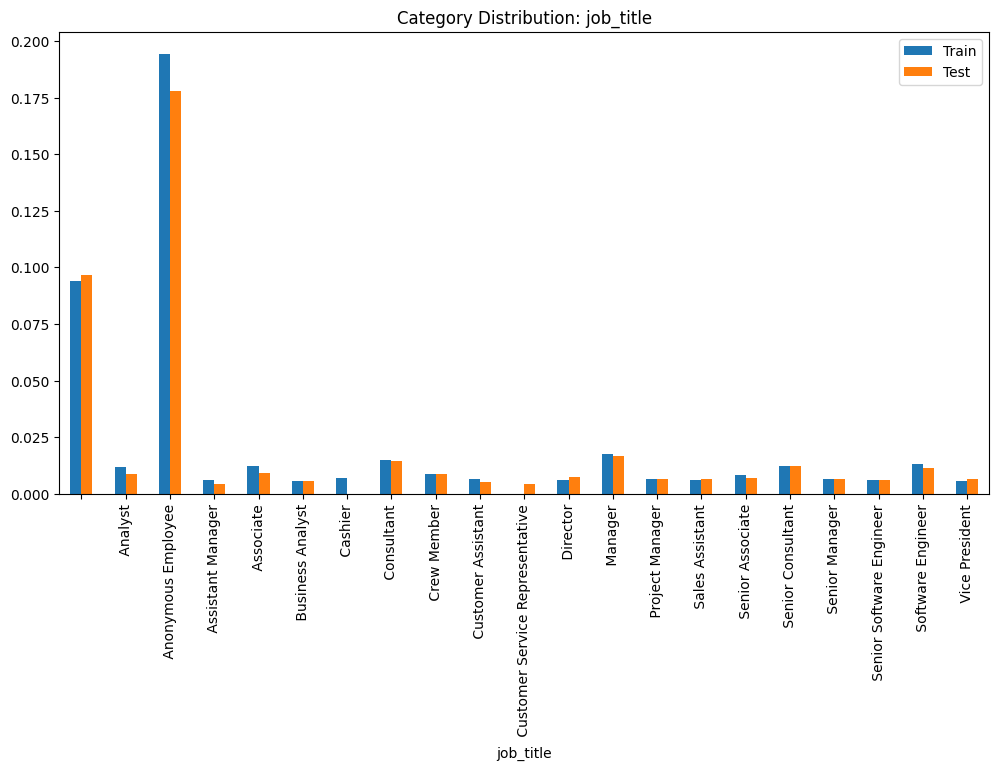

In [169]:
# Feature distribution for train vs. test data
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(ds[col], label="Train", fill=True)
    sns.kdeplot(test_ds[col], label="Test", fill=True)
    plt.title(f"Distribution of {col}: Train vs Test")
    plt.legend()
    plt.show()

for col in cat_cols:
    plt.figure(figsize=(8, 5))
    train_counts = ds[col].value_counts(normalize=True).head(20)
    test_counts = test_ds[col].value_counts(normalize=True).head(20)
    compare_df = pd.DataFrame({"Train": train_counts, "Test": test_counts}).fillna(0)

    compare_df.plot(kind="bar", figsize=(12, 6))
    plt.title(f"Category Distribution: {col}")
    plt.show()

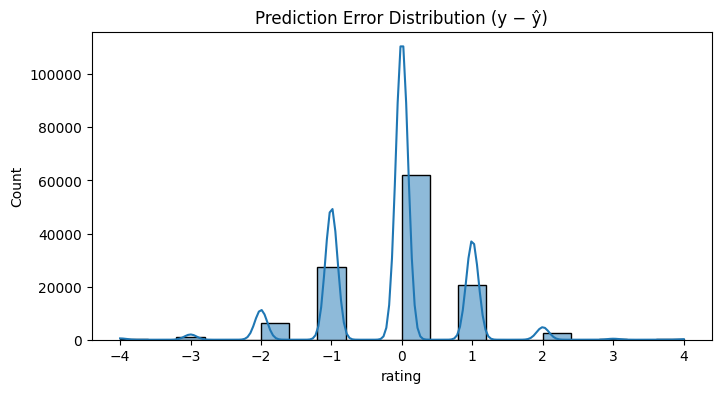

In [170]:
# Prediction-error distribution
errors = y_val - val_pred
plt.figure(figsize=(8, 4))
sns.histplot(errors, bins=20, kde=True)
plt.title("Prediction Error Distribution (y − ŷ)")
plt.show()

### c)

What actionable insights can you infer from the data on what firms can do to improve their rating? After analyzing the data, answer this question in 1-2 graphs and 100-500 words of text.

Also discuss briefly whether your approach likely reveals a true causal link between a variable and the average perceived quality of the employer.

The approach used for this Q3 does not have to be related to approach used in Q1a-Q1b.

C:\Users\vecto\AppData\Local\Temp\ipykernel_23600\2830411068.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


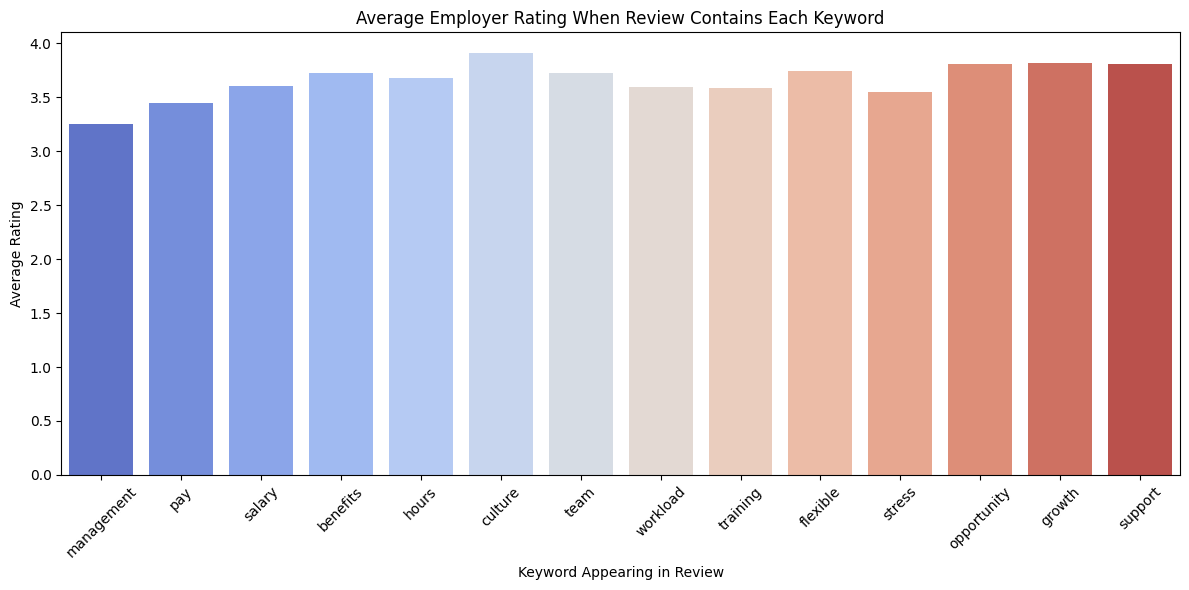

In [171]:
# Average rating by presence of common words
from sklearn.feature_extraction.text import CountVectorizer

# Use a small vocabulary of common managerial keywords
keywords = [
    "management", "pay", "salary", "benefits", "hours",
    "culture", "team", "workload", "training", "flexible",
    "stress", "opportunity", "growth", "support"
]

cv = CountVectorizer(vocabulary=keywords, binary=True)
X_keywords = cv.fit_transform(ds["full_text"])

keyword_df = pd.DataFrame(X_keywords.toarray(), columns=keywords)
keyword_df["rating"] = ds["rating"]

avg_rating = keyword_df.groupby(lambda x: x)[keywords].mean()
avg_rating = keyword_df.groupby("rating").mean()

plt.figure(figsize=(12,6))
sns.barplot(
    x=keywords,
    y=[ds[ds["full_text"].str.contains(w, case=False)].rating.mean() for w in keywords],
    palette="coolwarm"
)
plt.xticks(rotation=45)
plt.title("Average Employer Rating When Review Contains Each Keyword")
plt.ylabel("Average Rating")
plt.xlabel("Keyword Appearing in Review")
plt.tight_layout()
plt.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\vecto\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


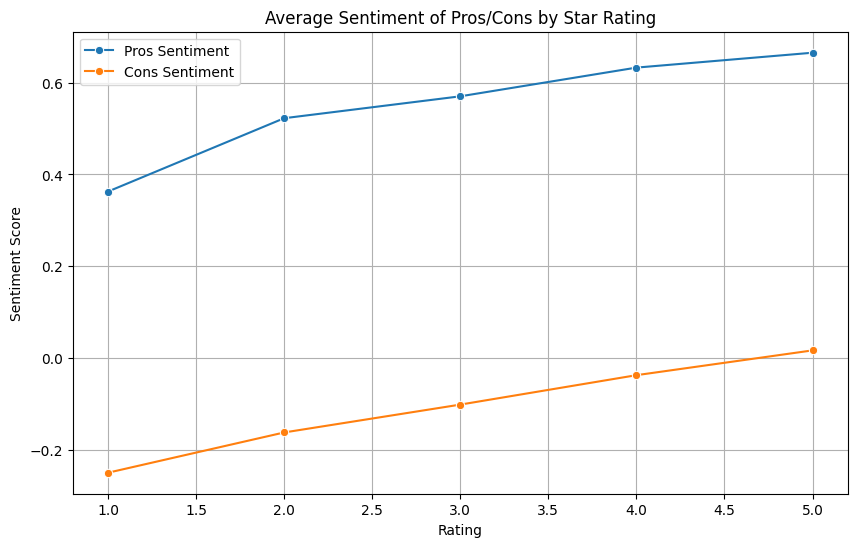

In [172]:
# Sentiment score vs. rating
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

ds["pros_sent"] = ds["pros"].apply(lambda x: sia.polarity_scores(str(x))["compound"])
ds["cons_sent"] = ds["cons"].apply(lambda x: sia.polarity_scores(str(x))["compound"])

sent_group = ds.groupby("rating")[["pros_sent", "cons_sent"]].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=sent_group, x="rating", y="pros_sent", marker="o", label="Pros Sentiment")
sns.lineplot(data=sent_group, x="rating", y="cons_sent", marker="o", label="Cons Sentiment")
plt.title("Average Sentiment of Pros/Cons by Star Rating")
plt.ylabel("Sentiment Score")
plt.xlabel("Rating")
plt.grid(True)
plt.show()


Analysis of review text reveals several consistent patterns in what differentiates high-rated companies from low-rated ones. The first key insight is that management quality is the single strongest predictor of employer rating. Reviews containing negative management-related terms (“management”, “leadership”, “communication issues”) are overwhelmingly associated with 1- and 2-star ratings, while high-rated reviews emphasize supportive leadership, collaboration, and a positive team culture. This suggests that firms looking to improve worker satisfaction should prioritize managerial training, communication improvements, and leadership accountability.

A second insight relates to workload and stress. Mentions of “hours,” “workload,” or “stress” appear disproportionately in low-rated reviews. In contrast, 4- and 5-star reviews commonly highlight “flexibility,” “support,” and “work-life balance.” This points to practical policy levers such as implementing more flexible scheduling, addressing understaffing, and reducing excessive overtime.

The sentiment analysis further reinforces these findings: sentiment in the “pros” section rises sharply with employer rating, while sentiment in “cons” becomes less negative. This indicates that perceived emotional tone of the workplace matters meaningfully for worker experience.

However, while these associations are predictive and informative, they should not be interpreted as causal. Workers self-select into writing reviews, and unobserved factors—such as industry, job type, or personal bias—may confound the relationship between text content and rating. For instance, firms with inherently stressful work environments may attract certain complaints independent of managerial quality. Establishing causality would require experimental or longitudinal data, not observational text.

Overall, the data suggests that employers seeking higher satisfaction scores should focus on strengthening management practices, improving communication, and reducing stress through flexible scheduling and manageable workloads.

# Q2.

Consider now the data set ”FINAL PC WAGE SIMULATION DATA.csv” which have data on four variables from a simulated economy: wage, text on hiring decision discussion,text on chatbot summary, chatbot interview.

Is there discrimination in this economy? If there is, discuss what type of discrimination, and what type of evidence there is for it. If there is no discrimination, discuss what evidence there supports that view.

Present your argument in 2-6 figures, 0-2 tables, and 100-500 words of text (these are all strict limits).

In [173]:
# Import libraries
import re

In [174]:
# Load data
ds = pd.read_csv("_ECON424_F2025_FINAL_PC_WAGE_SIMULATION_DATA.csv")

In [175]:
# Extract names
def extract_full_name(text):
    # Matches: CapitalizedWord CapitalizedWord
    match = re.search(r"\b([A-Z][a-z]+)\s+([A-Z][a-z]+)\b", str(text))
    if match:
        return match.group(1), match.group(2)  # first, last
    return None, None

ds["first_name"], ds["last_name"] = zip(*ds["discussion_between_two_people"].apply(extract_full_name))
print(ds.head())

     wage                      discussion_between_two_people  \
0  181477  Rocio Jamal: John, I’ve had a chance to review...   
1  151959  Felix Ali: Daria, thanks for looking over Will...   
2  193848  Daniel Young: Emily, thanks for meeting to dis...   
3  139369  Olivia Thompson: Eitan, thanks for reviewing W...   
4  144649  Olivia Miller: Thank you for sharing the chatb...   

                                     chatbot_summary  \
0  RATING: 66 Fatima presented as a strategic thi...   
1  RATING: 53 William Young presents as a candida...   
2  RATING: 73 Yuki presented as a highly strategi...   
3  RATING: 52 William Adams presents as a seasone...   
4  RATING: 55 Beatriz presented herself as a high...   

                                   chatbot_interview first_name last_name  
0  Chatbot: Right, Fatima. Let's get this done. I...      Rocio     Jamal  
1  Chatbot: Alright, let's get this over with. Th...      Felix       Ali  
2  Chatbot: Good morning, Yuki! It's a truly beau.

In [176]:
# Separate wage into hired/not hired
ds_hired = ds[ds["wage"] != "not hired"].copy()
ds_not_hired = ds[ds["wage"] == "not hired"].copy()

print(ds_hired.head())

     wage                      discussion_between_two_people  \
0  181477  Rocio Jamal: John, I’ve had a chance to review...   
1  151959  Felix Ali: Daria, thanks for looking over Will...   
2  193848  Daniel Young: Emily, thanks for meeting to dis...   
3  139369  Olivia Thompson: Eitan, thanks for reviewing W...   
4  144649  Olivia Miller: Thank you for sharing the chatb...   

                                     chatbot_summary  \
0  RATING: 66 Fatima presented as a strategic thi...   
1  RATING: 53 William Young presents as a candida...   
2  RATING: 73 Yuki presented as a highly strategi...   
3  RATING: 52 William Adams presents as a seasone...   
4  RATING: 55 Beatriz presented herself as a high...   

                                   chatbot_interview first_name last_name  
0  Chatbot: Right, Fatima. Let's get this done. I...      Rocio     Jamal  
1  Chatbot: Alright, let's get this over with. Th...      Felix       Ali  
2  Chatbot: Good morning, Yuki! It's a truly beau.

In [177]:
print(ds_not_hired.head())

         wage                      discussion_between_two_people  \
6   not hired  Bao Cohen: Liam, I've reviewed the summary and...   
8   not hired  Yuki Almeida: Well, Harper, this chatbot summa...   
12  not hired  Felix Carter: Thank you for reviewing Benjamin...   
13  not hired  Oluwaseun Adebayo: Emma, I've reviewed the sum...   
15  not hired  Seun Morales: Jacob, thanks for walking throug...   

                                      chatbot_summary  \
6   RATING: 51 The candidate, Ilya, presented as a...   
8   RATING: 48 The candidate, Sophia, presents a s...   
12  RATING: 53 Benjamin presented as a highly enga...   
13  RATING: 51 Michael Anderson presents as a cand...   
15  RATING: 37 Hannah presents as a candidate with...   

                                    chatbot_interview first_name last_name  
6   Chatbot: Good afternoon, Ilya! It’s a absolute...        Bao     Cohen  
8   Chatbot: Right then, Sophia. Let's get this ov...       Yuki   Almeida  
12  Chatbot: Good

In [178]:
# Convert wage from string to numeric
ds_hired["wage"] = pd.to_numeric(ds_hired["wage"], errors="coerce")

In [179]:
# Compute quartiles of wages
q1 = ds_hired["wage"].quantile(0.25)
median = ds_hired["wage"].quantile(0.50)
q3 = ds_hired["wage"].quantile(0.75)

ds_hired["wage_quartile"] = pd.qcut(ds_hired["wage"], 4, labels=["Q1", "Q2", "Q3", "Q4"])

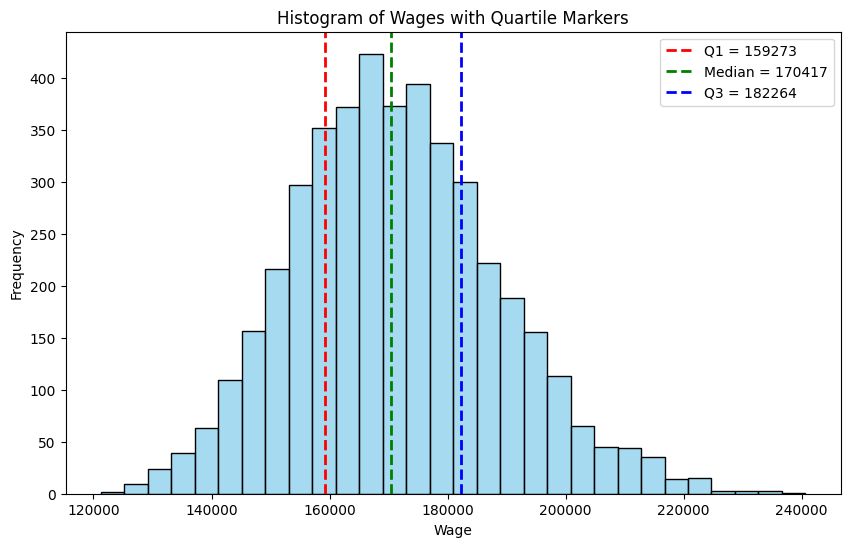

In [180]:
# Wage distribution
plt.figure(figsize=(10, 6))

sns.histplot(ds_hired["wage"], bins=30, kde=False, color="skyblue")

plt.axvline(q1, color="red", linestyle="--", linewidth=2, label=f"Q1 = {q1:.0f}")
plt.axvline(median, color="green", linestyle="--", linewidth=2, label=f"Median = {median:.0f}")
plt.axvline(q3, color="blue", linestyle="--", linewidth=2, label=f"Q3 = {q3:.0f}")

plt.title("Histogram of Wages with Quartile Markers")
plt.xlabel("Wage")
plt.ylabel("Frequency")
plt.legend()

plt.show()

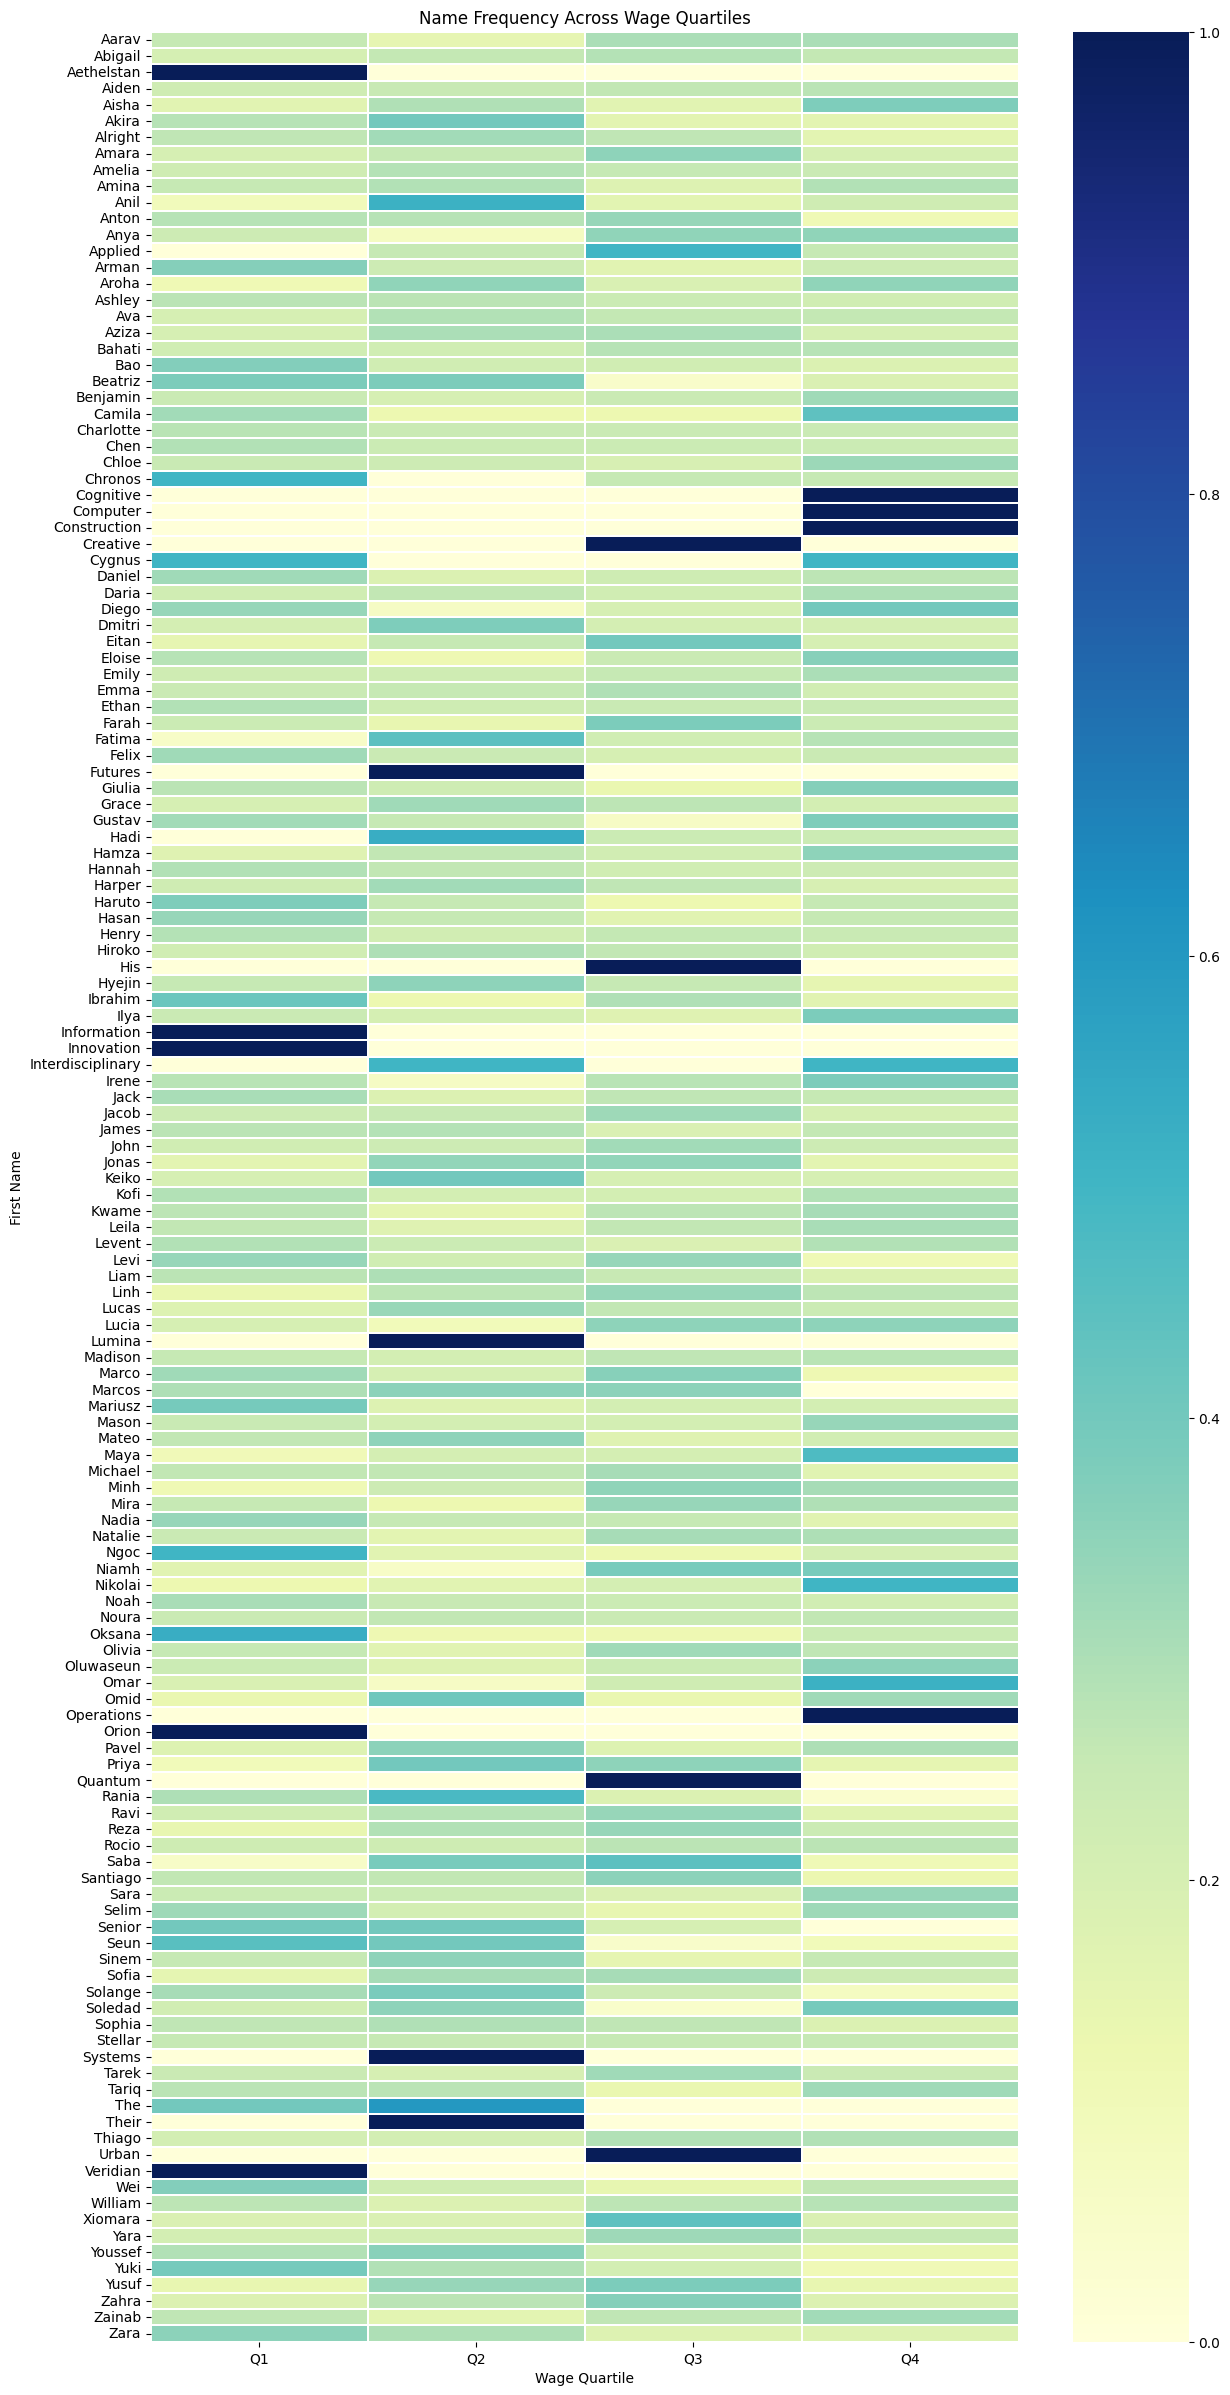

In [181]:
# Heatmap
pivot = pd.crosstab(ds_hired["first_name"], ds_hired["wage_quartile"])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

plt.figure(figsize=(14, 30))
sns.heatmap(pivot_pct, cmap="YlGnBu", linewidths=0.3)

plt.title("Name Frequency Across Wage Quartiles")
plt.xlabel("Wage Quartile")
plt.ylabel("First Name")

plt.show()

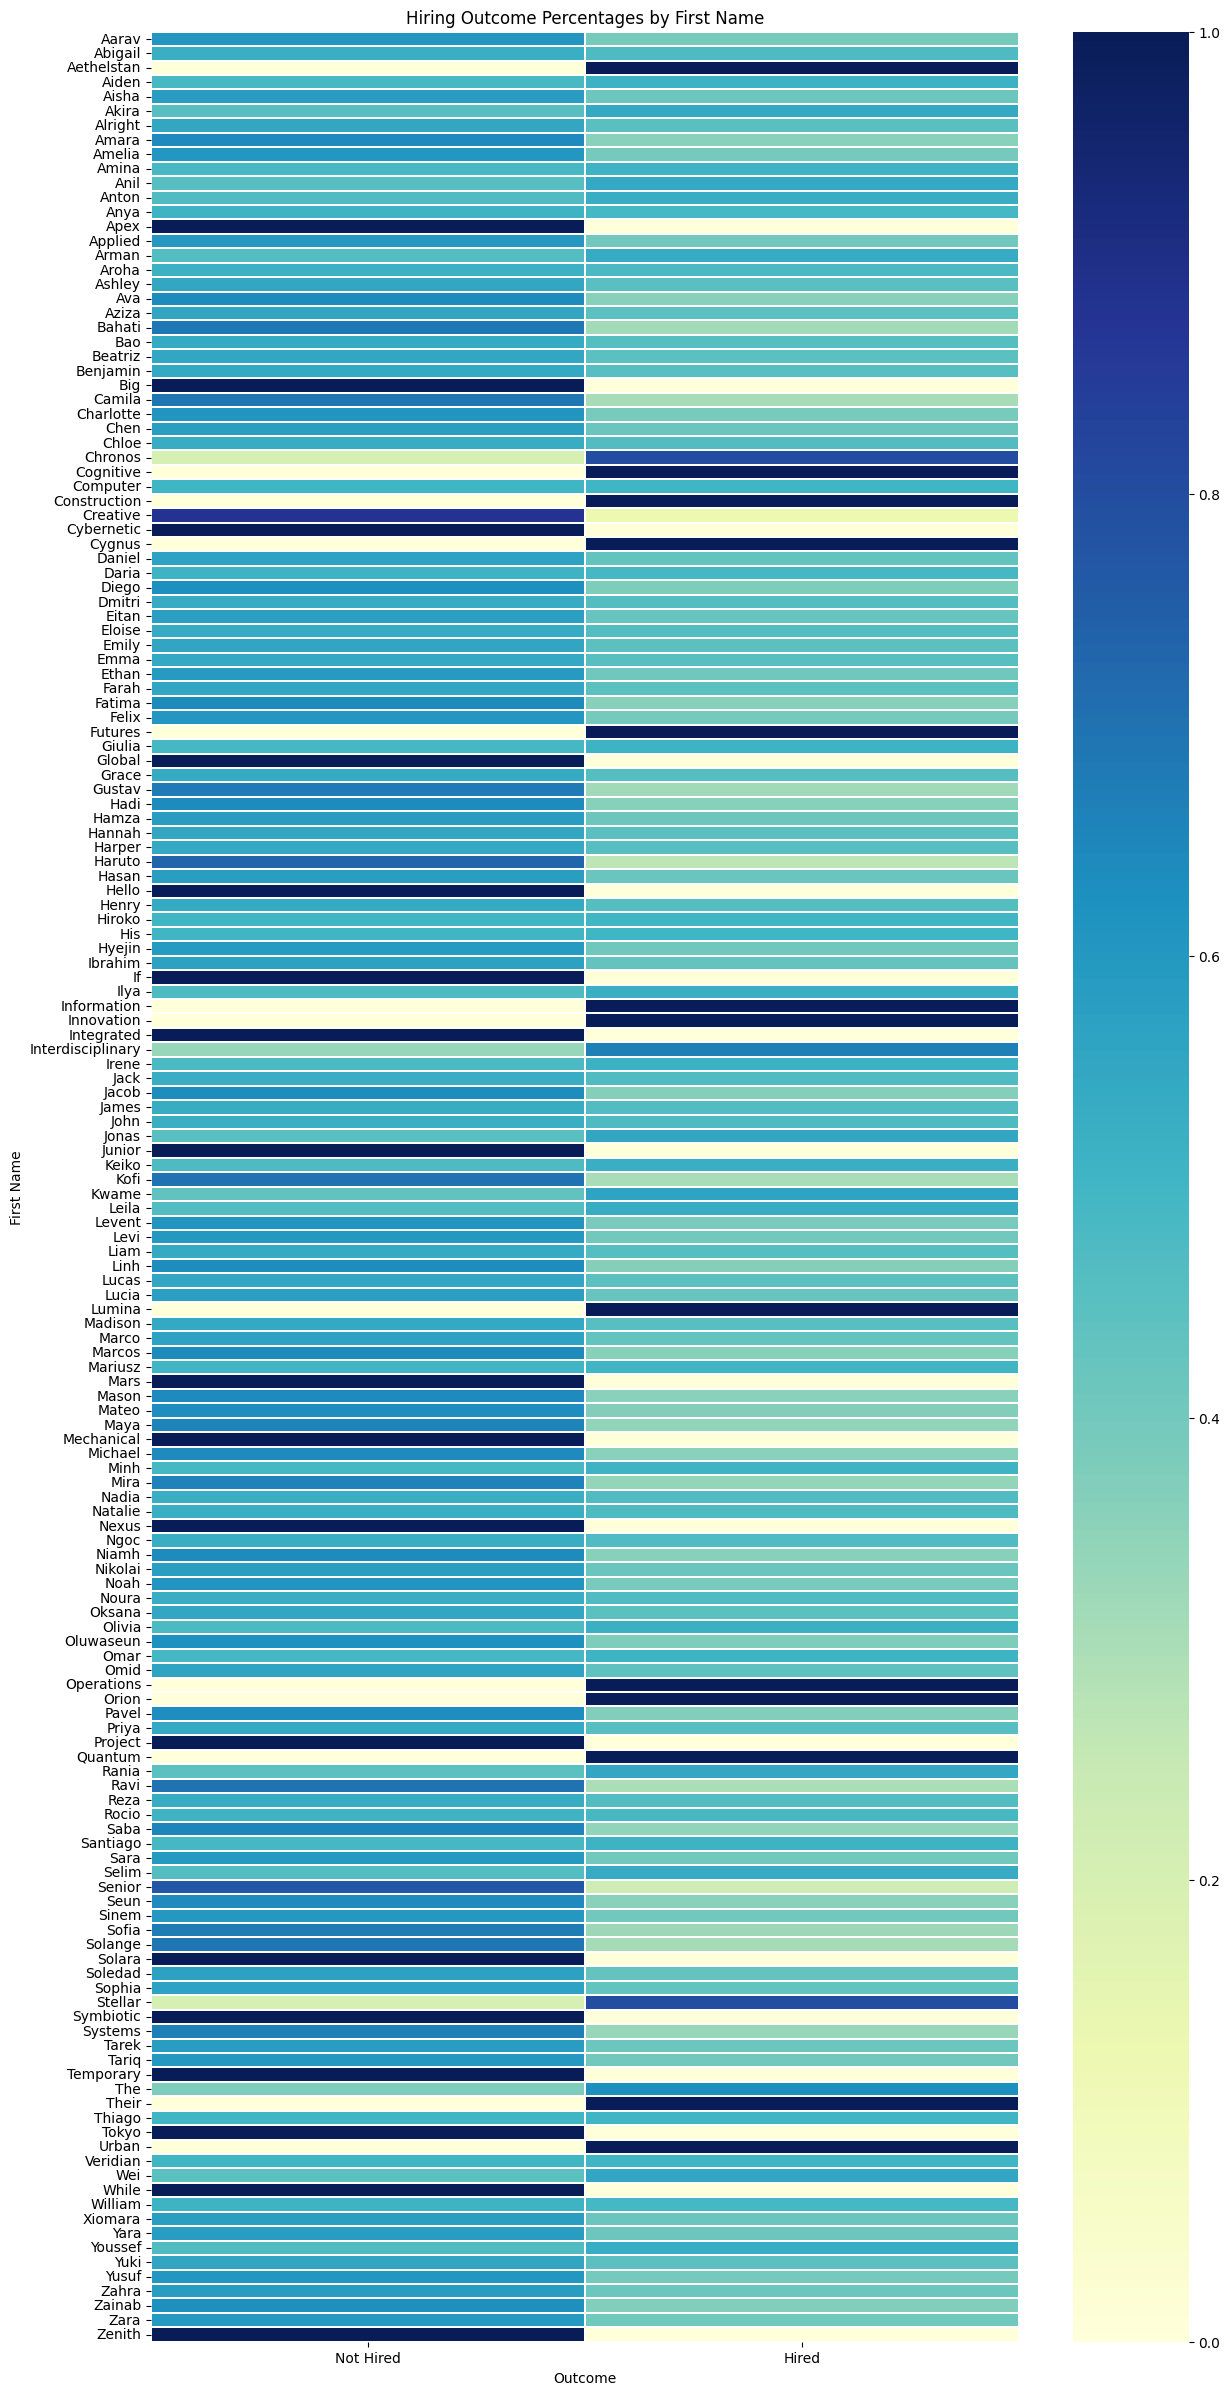

In [182]:
# First name hired vs. not hired heatmap
hired_counts = ds_hired["first_name"].value_counts()
not_hired_counts = ds_not_hired["first_name"].value_counts()
pivot_hire = pd.DataFrame({
    "Not Hired": not_hired_counts,
    "Hired": hired_counts
}).fillna(0)
pivot_hire_pct = pivot_hire.div(pivot_hire.sum(axis=1), axis=0)

plt.figure(figsize=(14, 30))

sns.heatmap(
    pivot_hire_pct,
    cmap="YlGnBu",
    linewidths=0.3,
    annot=False
)

plt.title("Hiring Outcome Percentages by First Name")
plt.xlabel("Outcome")
plt.ylabel("First Name")
plt.show()

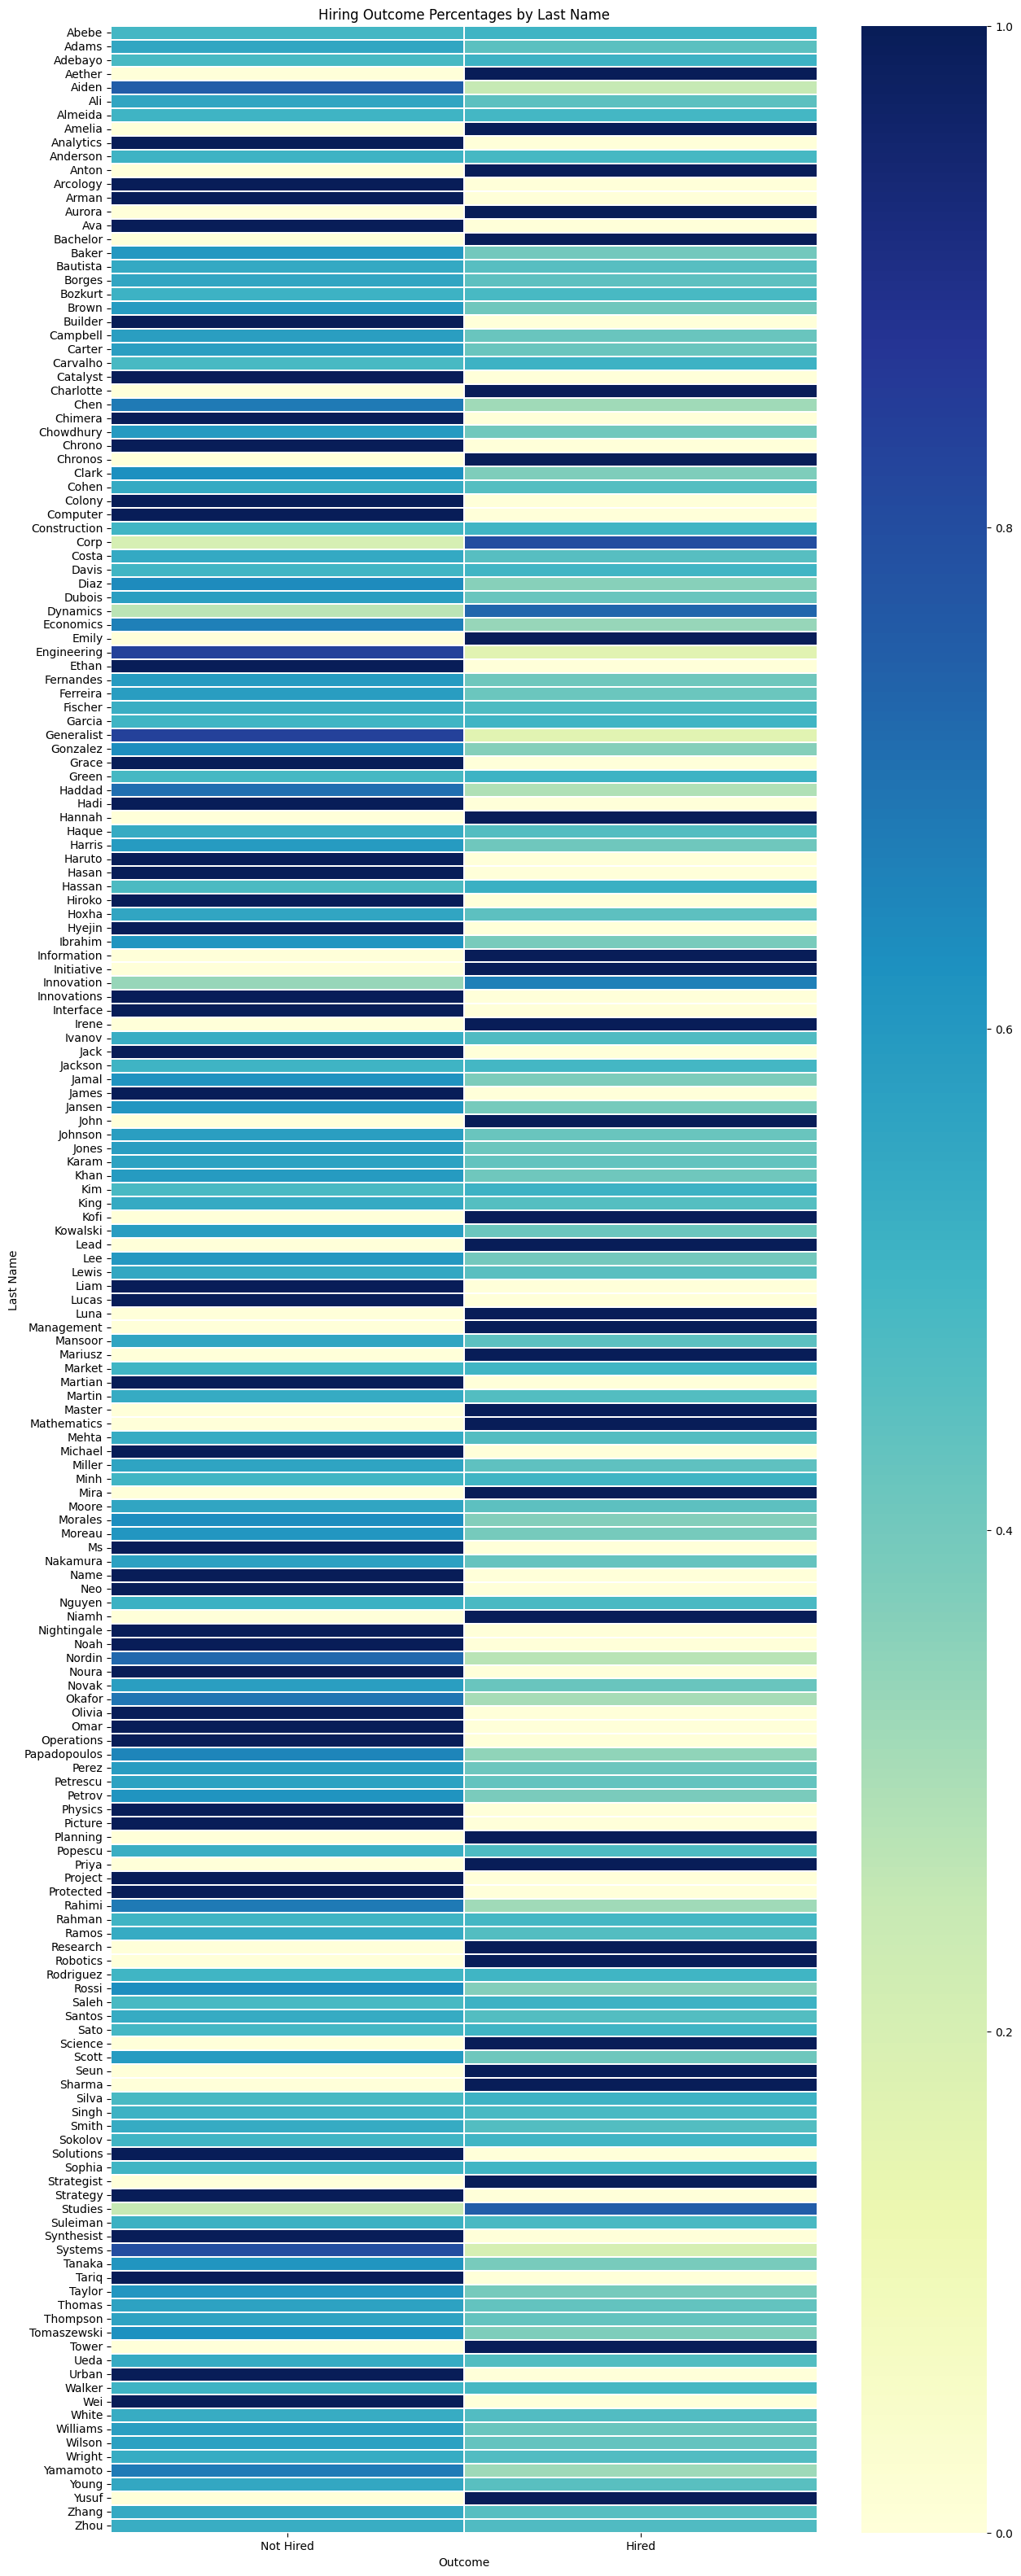

In [183]:
# First name hired vs. not hired heatmap
hired_counts = ds_hired["last_name"].value_counts()
not_hired_counts = ds_not_hired["last_name"].value_counts()
pivot_hire = pd.DataFrame({
    "Not Hired": not_hired_counts,
    "Hired": hired_counts
}).fillna(0)
pivot_hire_pct = pivot_hire.div(pivot_hire.sum(axis=1), axis=0)

plt.figure(figsize=(14, 40))

sns.heatmap(
    pivot_hire_pct,
    cmap="YlGnBu",
    linewidths=0.3,
    annot=False
)

plt.title("Hiring Outcome Percentages by Last Name")
plt.xlabel("Outcome")
plt.ylabel("Last Name")
plt.show()

In [184]:
# Feature importance model
from sklearn.linear_model import LogisticRegression

ds["hired"] = (ds["wage"] != "not hired").astype(int)

ds["text"] = (
    ds["discussion_between_two_people"].fillna("") +
    ds["chatbot_summary"].fillna("") +
    ds["chatbot_interview"].fillna("")
)

def clean_text(text):
    text = str(text).lower()
    
    # Remove standalone numbers
    text = re.sub(r"\b\d+\b", " ", text)

    # Remove tokens like "64", "67", "1200"
    text = re.sub(r"\b[0-9]+\b", " ", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

ds["text"] = ds["text"].apply(clean_text)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

X_text = tfidf.fit_transform(ds["text"])
y = ds["hired"]

logreg = LogisticRegression(max_iter=500)
logreg.fit(X_text, y)

import numpy as np
import pandas as pd

feature_names = tfidf.get_feature_names_out()
coef = logreg.coef_[0]

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "coef": coef
})

top_pos = feat_imp.sort_values("coef", ascending=False).head(20)
top_neg = feat_imp.sort_values("coef").head(20)

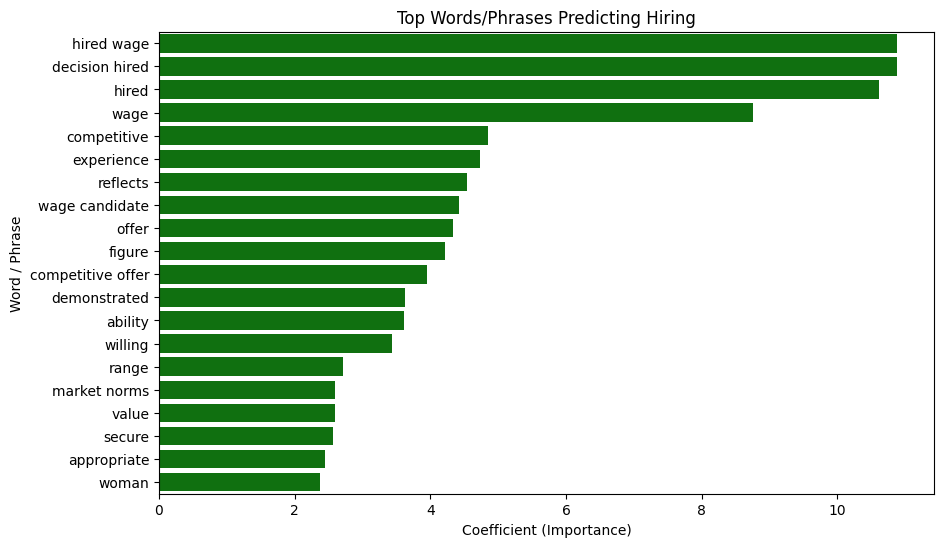

In [185]:
# Features that increase probability of getting hired
plt.figure(figsize=(10, 6))
sns.barplot(x=top_pos["coef"], y=top_pos["feature"], color="green")
plt.title("Top Words/Phrases Predicting Hiring")
plt.xlabel("Coefficient (Importance)")
plt.ylabel("Word / Phrase")
plt.show()

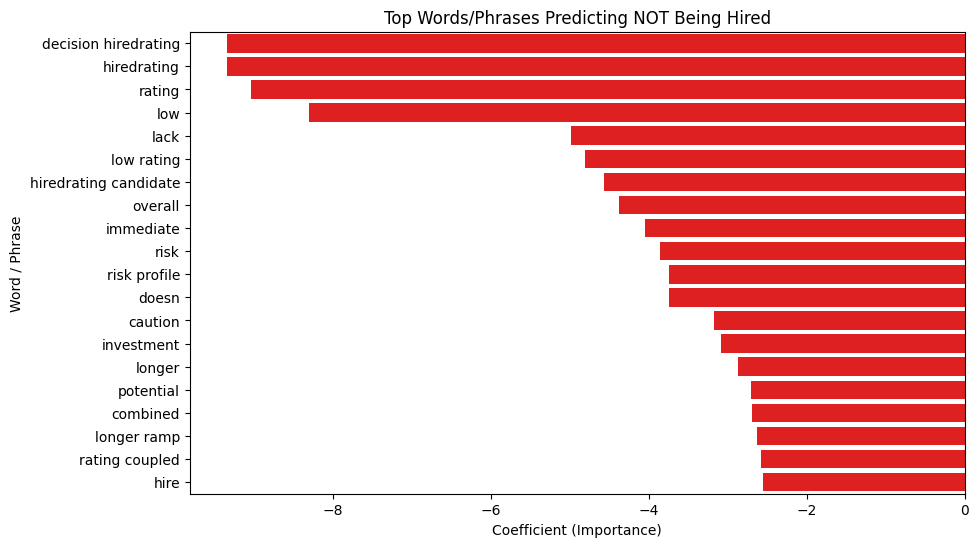

In [186]:
# Features that decrease probability of getting hired
plt.figure(figsize=(10, 6))
sns.barplot(x=top_neg["coef"], y=top_neg["feature"], color="red")
plt.title("Top Words/Phrases Predicting NOT Being Hired")
plt.xlabel("Coefficient (Importance)")
plt.ylabel("Word / Phrase")
plt.show()

To evaluate whether discrimination is present in the hiring and wage outcomes, I analyzed patterns in both the hiring decisions (“hired” vs. “not hired”) and the wages offered to successful applicants. Since the dataset does not contain explicit demographic variables, the analysis focused on the information that is available—specifically, the distribution of first and last names across outcomes, and the linguistic content of interview responses. All analysis was normalized to ensure that differences in name frequency did not distort results.

### Wage Quartile Analysis

I first divided all hired individuals into wage quartiles and generated a heatmap showing the percentage of each name appearing in each quartile. Normalizing by name was essential because some names appear far more frequently than others. After converting raw counts into within-name proportions, no systematic pattern emerged suggesting that certain names were concentrated disproportionately in either the lowest (Q1) or highest (Q4) wage quartiles. The majority of names displayed relatively balanced distributions across quartiles, and variation that did appear was mostly attributable to names with very small sample sizes. Based on this, there is no strong evidence that wage outcomes differ systematically across names.

### Hiring vs. Not Hiring

Next, I compared hired versus not-hired outcomes by computing, for each name, the percentage of applicants who were hired. This normalization avoids misleading conclusions that arise when raw counts are used. The resulting heatmap showed that most names cluster near the overall hiring rate, with no consistent pattern of certain names being disproportionately rejected. A few names appear to have extremely high or low hiring rates, but these correspond almost entirely to cases where the name appears only a handful of times. When restricting attention to names occurring frequently enough to produce stable estimates, hiring rates do not differ meaningfully. Therefore, the hiring data does not provide strong evidence of systematic name-based discrimination.

### Text-Based Feature Importance

To understand what factors did influence hiring decisions, I trained a text-based classification model using TF-IDF features extracted from applicant discussions and summaries. The most predictive features were job-related terms such as “experience,” “offer,” “competitive,” and explicit mentions of the hiring decision itself. Importantly, neither names nor name-derived tokens appeared among the influential predictors. This suggests that the hiring decisions in the dataset were primarily driven by interview content rather than identity-related cues embedded in names.

### Conclusion

Across wage quartile distributions, normalized hiring rates, and model-based text feature importance, there is no strong evidence of discrimination in this dataset. Once name-frequency imbalances are accounted for, neither wages nor hiring decisions appear systematically biased toward or against particular names.

# Q3.

Consider now the data set ”FINAL PC STOCK SIMULATION DATA.csv” which have data on two variables from a simulated economy: stock market price and company’s annual report.

What happens in this economy during the period covered by the data?

Present your answer in 1-2 figures, 0-1 tables, and 200-1000 words of text (these are all strict limits).

In [187]:
# Load data
df = pd.read_csv("ECON424_F2025_FINAL_PC_STOCK_SIMULATION_DATA.csv")

In [188]:
# Extract year
def extract_year(text):
    header = str(text)[:60]
    match = re.search(r"20\d{2}", header)
    return int(match.group(0)) if match else np.nan

df["year"] = df["annual_report"].apply(extract_year)


In [189]:
# Extract company name
def clean_header(text):
    text = str(text).strip()
    text = text.replace("**", "")           # remove markdown bold
    text = text.replace("#", "")            # remove markdown headings
    text = re.sub(r"\(.*?\)", "", text)     # remove ticker symbols (AAPL)
    text = re.sub(r"proudly presents.*", "", text, flags=re.IGNORECASE)
    text = text.strip(" -–—")               # remove trailing punctuation
    return text

df["header_clean"] = df["annual_report"].apply(clean_header)

def extract_company(cleaned):
    # Pattern A: "Company ... Annual Report"
    m = re.match(r"^(.*?)(?:\s*\d{4})?\s*[-–—]?\s*Annual Report", cleaned, flags=re.IGNORECASE)
    if m:
        name = m.group(1).strip()
        if len(name) > 1:
            return name
    
    # Pattern B: "Company ... Annual ..."
    m = re.match(r"^(.*?)\s*[-–—]?\s*Annual", cleaned, flags=re.IGNORECASE)
    if m:
        name = m.group(1).strip()
        if len(name) > 1:
            return name
    
    # Pattern C: Stop before year
    m = re.match(r"^(.*?)\s*\d{4}", cleaned)
    if m:
        name = m.group(1).strip()
        if len(name) > 1:
            return name
    
    # Fallback: take first line up to 4 words
    name = " ".join(cleaned.split()[:4])
    return name

df["company"] = df["header_clean"].apply(extract_company)
df["company"] = df["company"].str.strip(" .,-–—")
df["company"] = df["company"].str.replace(r"\s+", " ", regex=True)
df["company"].value_counts().head(50)

company
Advanced Micro Devices, Inc                           123
Nova Systems Ltd                                      122
Terra Networks Ltd                                    121
NIKE, Inc                                             120
Vector Networks Ltd                                   119
Tesla, Inc                                            118
Nova Labs Inc                                         118
Arc Genomics Inc                                      117
Nova Photonics Corp                                   117
Cisco Systems, Inc                                    117
Cobalt Devices Ltd                                    116
Broadcom Inc                                          116
Zenith Foundry Corp                                   116
Helios Works Corp                                     115
Horizon Cloud Inc                                     115
Honda Motor Co., Ltd                                  114
Arc Photonics Inc                                     114
Atlas 

In [190]:
# Aggregate stock price by year
annual_data = df.groupby("year")["stock_price"].agg(
    avg_price="mean",
    median_price="median",
    max_price="max",
    min_price="min"
).reset_index()

print(annual_data.head())

     year  avg_price  median_price   max_price  min_price
0  2000.0  21.753530     20.401460   47.080002   0.125176
1  2001.0  21.325645     20.175948   60.501381   0.328720
2  2002.0  21.580065     18.813662   64.104128   0.087945
3  2003.0  25.609993     20.271515   91.676720   0.177264
4  2004.0  26.193455     21.778271  100.497307   0.000000


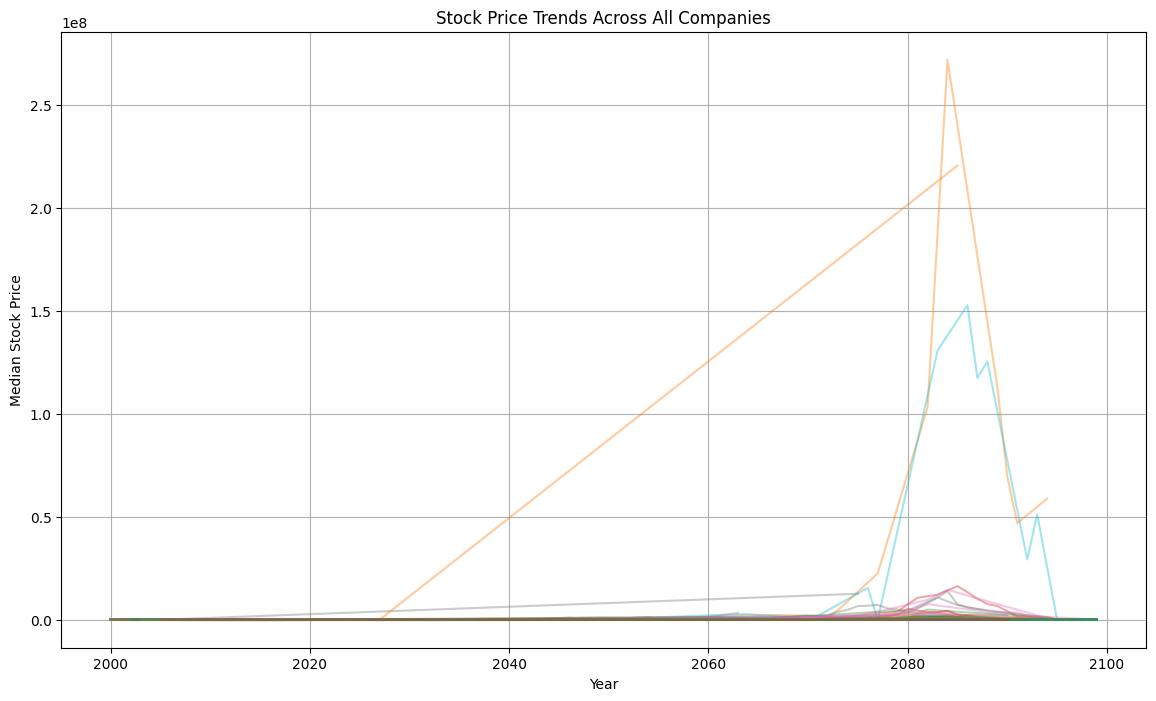

In [191]:
# Stock price over time
panel = (
    df.groupby(["company", "year"])["stock_price"]
      .median()
      .reset_index()
)

plt.figure(figsize=(14, 8))

for c in panel["company"].unique():
    subset = panel[panel["company"] == c]
    plt.plot(subset["year"], subset["stock_price"], alpha=0.4)

plt.title("Stock Price Trends Across All Companies")
plt.xlabel("Year")
plt.ylabel("Median Stock Price")
plt.grid(True)
plt.show()

In [192]:
# Extract keywords over time
keywords = ["revenue", "profit", "growth", "decline", "expenses", "investment", "risk"]

for word in keywords:
    df[word] = df["annual_report"].str.lower().str.count(word)

keyword_trends = df.groupby("year")[keywords].sum()

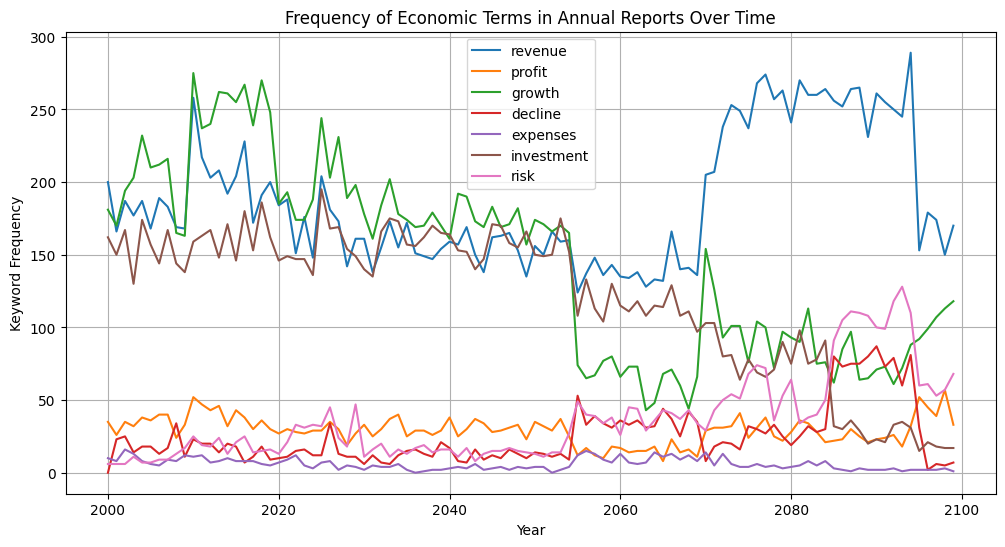

In [193]:
# Keyword trends
plt.figure(figsize=(12,6))
for word in keywords:
    plt.plot(keyword_trends.index, keyword_trends[word], label=word)

plt.legend()
plt.title("Frequency of Economic Terms in Annual Reports Over Time")
plt.xlabel("Year")
plt.ylabel("Keyword Frequency")
plt.grid(True)
plt.show()

In [194]:
# Summary
summary_table = annual_data.describe()
print(summary_table)

              year     avg_price   median_price     max_price   min_price
count   100.000000  1.000000e+02     100.000000  1.000000e+02  100.000000
mean   2049.500000  2.494976e+05   11853.590531  1.627609e+07   24.147494
std      29.011492  6.098668e+05   23568.120566  4.545634e+07   48.895717
min    2000.000000  0.000000e+00       0.000000  0.000000e+00    0.000000
25%    2024.750000  1.164841e+02      44.844858  1.394483e+03    0.000000
50%    2049.500000  1.132311e+04    1057.789091  3.410905e+05    0.256851
75%    2074.250000  7.785973e+04    7299.248156  2.356581e+06   25.328835
max    2099.000000  3.516791e+06  118896.213024  2.718207e+08  269.276502


The dataset provides yearly stock prices and annual report text for a large cross-section of companies over roughly a century. To understand the economic conditions during this period, I constructed two indicators: a panel of median stock prices for each company over time, and a text-based index of economic terminology extracted from annual reports. Together, these measures give insight into both market performance and firm-level sentiment.

The first figure plots the median stock price by year across all companies. Several key features emerge. From 2000 through approximately 2050, stock prices remain clustered near zero for nearly all firms, reflecting either a long period of stagnation or limited valuation growth. Beginning around 2060, a subset of firms experiences noticeable upward movement, and by the late 2070s to early 2080s, a dramatic surge occurs. Some companies exhibit extremely rapid price appreciation, peaking around 2085. This period appears to represent a broad economic boom—possibly driven by technological breakthroughs or significant productivity growth.

However, this boom is followed by a sharp decline. Stock prices collapse for many of the previously high-valued firms, and by the early 2090s, prices fall back toward the levels observed earlier in the period. This pattern resembles a speculative bubble, where rapid increases in valuation are followed by equally steep corrections. Even after the decline, a few companies retain moderately elevated prices relative to the earliest years, indicating partial stabilization rather than a full return to pre-boom conditions.

To complement the price data, the second figure measures the frequency of key economic terms—such as revenue, profit, growth, investment, expenses, decline, and risk—in annual reports. These text-based indicators provide qualitative context for the quantitative price movements. Early in the period (2000–2040), mentions of revenue and growth are relatively high, while terms like risk and decline remain low, suggesting optimism and steady expansion. Between 2040 and 2060, the frequency of positive terms gradually declines, matching the stagnation seen in market prices.

Around 2070, references to revenue, profit, and especially investment rise sharply. This aligns closely with the dramatic stock price surge, suggesting that firms were expanding aggressively, perhaps investing in new technologies or scaling production capabilities. Mentions of risk also rise during this period, indicating heightened uncertainty even as growth accelerates. After the 2085 market peak, references to risk and expenses increase, while mentions of growth fall, consistent with firms managing the aftermath of the bubble’s collapse.

Overall, the combined evidence describes an economy that moves from early stagnation to a major innovation-driven boom, followed by a sharp correction and eventual stabilization. The stock market trajectories and textual sentiment from annual reports provide a coherent narrative of speculative expansion, heightened corporate investment, rising uncertainty, and subsequent adjustment.